In [22]:
import os
import torch
import numpy as np
from datasets import load_dataset
from huggingface_hub import snapshot_download

In [26]:
repo_id = 'eturok-weizmann/vibrations'
# ds = load_dataset(repo_id, split='train', columns=["sample_idx", "x_position", "y_position", "object", "fps"])
ds = load_dataset(repo_id, split='train')
snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz")

Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


In [29]:
ds

Dataset({
    features: ['x_position', 'y_position', 'raw_image', 'cropped_image', 'overlay_image', 'object', 'speakers', 'fps', 'n_objects', 'box_material', 'experiment_config', 'sample_idx'],
    num_rows: 1
})

In [27]:
idx = 4
ex = ds[idx]

IndexError: Invalid key: 4 is out of bounds for size 1

In [13]:
ex

{'x_position': 554.4198635482102,
 'y_position': 426.6459964612163,
 'raw_image': <PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=2056x1542>,
 'cropped_image': <PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=1069x956>,
 'overlay_image': <PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=1069x956>,
 'object': 'empty',
 'speakers': [1, 0, 0, 0],
 'fps': 2500,
 'n_objects': 1,
 'box_material': 'cardboard',
 'experiment_config': '{"ROI_ROW_HEIGHT": 30, "N_ROI_ROWS": 10, "N_ROI_COLUMNS": 10, "ROI_COLUMN_WIDTH": 70, "CALIBRATION_FPS": 500, "CALIBRATION_EXPOSURE": 30, "CALIBRATION_GAIN": 3, "FPS": 2500, "EXPOSURE": 150, "GAIN": 1, "BUFFER_PART_COUNT": 3000, "EXPOSURE_MS": 30, "FRAME_RATE": 30, "PIXEL_CLOCK": 86, "CAMERA_GAIN": 60, "RESIZE_FACTOR": 0.75, "GAMMA": 1.0, "AUDIO_FILE": "..\\\\data\\\\audio_samples\\\\chirp_50_1000_3.0sec.wav", "N_CAPTURE_SECONDS": 3.1, "speakers": [1, 0, 0, 0], "object": "empty", "n_objects": 1, "box_material": "cardboard"}',
 'sample_idx': 3}

In [14]:
data = np.load(os.path.join(snapshot_dir, f"data/sample_{ds[idx]['sample_idx']}.npz"))
shifts, mask = torch.from_numpy(data['shifts']), torch.from_numpy(data['mask'].astype(np.float32)) 

In [20]:
shifts

tensor([[[ 0.0000e+00,  0.0000e+00],
         [ 4.5432e-02, -5.6444e-01],
         [ 5.7188e-02, -5.6429e-01],
         ...,
         [ 7.7932e-01, -6.6740e-01],
         [ 7.7259e-01, -6.6472e-01],
         [ 7.8211e-01, -6.6546e-01]],

        [[ 0.0000e+00,  0.0000e+00],
         [-1.2030e-02, -2.7515e-01],
         [-2.2535e-02, -2.7416e-01],
         ...,
         [-7.4086e-01, -2.7043e-01],
         [-7.4853e-01, -2.6930e-01],
         [-7.4612e-01, -2.6104e-01]],

        [[ 0.0000e+00,  0.0000e+00],
         [-3.8284e-02, -4.8552e-01],
         [-3.5654e-02, -4.7700e-01],
         ...,
         [ 2.4123e-01,  5.4290e-01],
         [ 2.5298e-01,  5.4503e-01],
         [ 2.5301e-01,  5.4522e-01]],

        ...,

        [[ 0.0000e+00,  0.0000e+00],
         [ 1.0049e-02, -4.7321e-04],
         [ 4.6447e-03,  1.2224e-02],
         ...,
         [ 1.0197e+00,  1.1696e+01],
         [ 1.0216e+00,  1.1696e+01],
         [ 1.0237e+00,  1.1691e+01]],

        [[ 0.0000e+00,  0.0000e+00

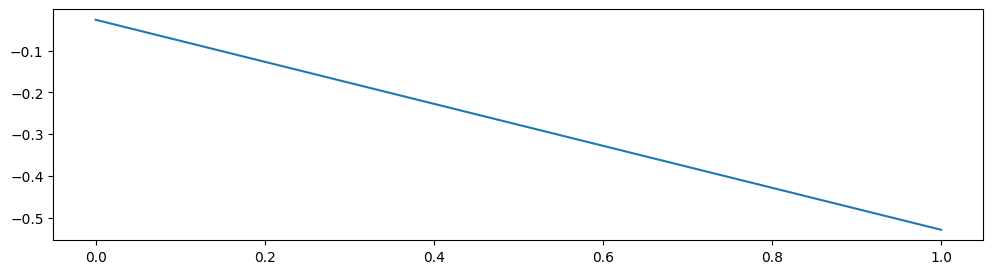

In [21]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(shifts[8][:][1])
plt.show()